### TrOCR: fine-tune and evaluate (Synthetic Handwriting)

Fine-tune `microsoft/trocr-base-handwritten` on synthetic training data and compare the **pretrained** base model to the **fine-tuned** checkpoint on the real held-out test set (WER, CER, line accuracy).

**Data:** synthetic train labels/images from `synthetic_dataset/Train_Label.csv` + `synthetic_dataset/Train_Set/` (falls back to `synthetic_dataset/` if needed), and real test labels/images from `real_dataset/RxHandBD-ML/Test_Label.csv` + `real_dataset/RxHandBD-ML/Test_Set/`. **First run** downloads TrOCR (network required).



### Imports

In [20]:
import json
import random
from contextlib import nullcontext
from pathlib import Path
from typing import Callable, Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from jiwer import cer, process_words, wer
from PIL import Image, ImageEnhance, ImageFilter
from torch.utils.data import Dataset
from transformers import (
    EarlyStoppingCallback,
    EvalPrediction,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    TrOCRProcessor,
    VisionEncoderDecoderModel,
)

### Tuning: change the next cell (batch size, epochs, paths, seed).

In [21]:
# --- config ---
from pathlib import Path
import os

TRAIN_LABEL_CSV = Path("synthetic_dataset/Train_Label.csv")
TRAIN_IMAGE_DIR = Path("synthetic_dataset/Train_Set/")
if not TRAIN_IMAGE_DIR.is_dir():
    TRAIN_IMAGE_DIR = Path("synthetic_dataset/")
TEST_LABEL_CSV = Path("real_dataset/RxHandBD-ML/Test_Label.csv")
TEST_IMAGE_DIR = Path("real_dataset/RxHandBD-ML/Test_Set/")
PRETRAINED = "microsoft/trocr-base-handwritten"
OUTPUT_DIR = Path("outputs/trocr-synthetic")

SEED = 42
VAL_FRACTION = 0.08
MAX_LABEL_TOKENS = 64
EPOCHS = 3
TRAIN_BATCH = 4
EVAL_BATCH = 4
LEARNING_RATE = 5e-5
WARMUP_RATIO = 0.05
LOGGING_STEPS = 25
# 1.0 is the HF default and the value used by standard TrOCR recipes; values much
# smaller (e.g. 0.1) clip almost every step and effectively freeze training.
MAX_GRAD_NORM = 1.0
GEN_MAX_LEN = 64
# Greedy during epoch eval keeps training fast; final test eval re-runs with
# beam search (cell that calls `evaluate_model_on_df` on the test set).
GEN_NUM_BEAMS = 1
FINAL_EVAL_NUM_BEAMS = 4

# Regularization / stopping
WEIGHT_DECAY = 0.01
LABEL_SMOOTHING = 0.0
EARLY_STOPPING_PATIENCE = 2

# Data augmentation toggle (train split only)
USE_AUGMENTATION = False

# Optional throughput knobs
GRAD_ACCUM_STEPS = 1

# DataLoader workers: parallel image decode + batching (faster on CPU I/O). Use 0 if workers crash.
DATALOADER_NUM_WORKERS = 6

In [23]:
# For reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# Read the training and test data
train_df = pd.read_csv(TRAIN_LABEL_CSV)
test_df = pd.read_csv(TEST_LABEL_CSV)
train_df.columns = train_df.columns.str.strip()
test_df.columns = test_df.columns.str.strip()

# Check to see if the training and test data has the correct columns
assert {"Images", "Text"}.issubset(train_df.columns)
assert {"Images", "Text"}.issubset(test_df.columns)

# Shuffle the training data
train_df = train_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

# Split the training data into training and validation sets
n_val = max(1, round(len(train_df) * VAL_FRACTION))
val_df = train_df.tail(n_val).reset_index(drop=True)
train_only = train_df.iloc[:-n_val].reset_index(drop=True)

# Check to see if the training and test data exists
assert (TRAIN_IMAGE_DIR / str(train_only.iloc[0]["Images"])).is_file()
assert (TEST_IMAGE_DIR / str(test_df.iloc[0]["Images"])).is_file()

# Check to see if there is a GPU available. If not, the model will run on the CPU.
device = "cuda" if torch.cuda.is_available() else "cpu"

# Print the number of training, validation, and test data.
print(f"train={len(train_only)} | val={len(val_df)} | test={len(test_df)}")
print(f"device={device}")

train=4106 | val=357 | test=1115
device=cuda


### Dataset and Dataloaders

In [24]:
def make_train_image_augmenter(seed: int = SEED) -> Callable[[Image.Image], Image.Image]:
    """Conservative PIL-only augmentations for handwritten OCR lines.

    Designed to perturb without destroying legibility: small rotation, mild
    brightness/contrast jitter, and an occasional light blur. Each worker gets
    an independent RNG seeded once.
    """
    rng = random.Random(seed)

    def _augment(img: Image.Image) -> Image.Image:
        if rng.random() < 0.5:
            img = img.rotate(rng.uniform(-2.0, 2.0), resample=Image.BILINEAR, fillcolor=(255, 255, 255))
        if rng.random() < 0.7:
            img = ImageEnhance.Brightness(img).enhance(rng.uniform(0.85, 1.15))
        if rng.random() < 0.7:
            img = ImageEnhance.Contrast(img).enhance(rng.uniform(0.85, 1.15))
        if rng.random() < 0.2:
            img = img.filter(ImageFilter.GaussianBlur(radius=rng.uniform(0.2, 0.8)))
        return img

    return _augment


class TrOCRLineDataset(Dataset):
    """One line image + ground-truth text, encoded for TrOCR.

    Labels are returned unpadded; the collator handles per-batch padding to the
    longest label, replacing pad tokens with -100 so they're ignored by the loss.
    """

    def __init__(
        self,
        df: pd.DataFrame,
        image_dir: Path,
        processor,
        max_length: int,
        augment: bool = False,
    ) -> None:
        self.df = df.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.processor = processor
        self.max_length = int(max_length)
        self.augmenter = make_train_image_augmenter() if augment else None

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int) -> dict:
        row = self.df.iloc[idx]
        name = str(row["Images"])
        text = str(row["Text"])
        image = Image.open(self.image_dir / name).convert("RGB")
        if self.augmenter is not None:
            image = self.augmenter(image)
        enc = self.processor(
            image,
            text,
            return_tensors="pt",
            max_length=self.max_length,
            truncation=True,
        )
        return {
            "pixel_values": enc["pixel_values"].squeeze(0),
            "labels": enc["labels"].squeeze(0),
        }


class TrOCRDataCollator:
    """Stack images; right-pad variable-length labels with -100 so they're ignored by loss."""

    def __init__(self, pad_token_id: int) -> None:
        self.pad_token_id = int(pad_token_id)

    def __call__(self, features: List[dict]) -> dict:
        pixel_values = torch.stack([f["pixel_values"] for f in features], dim=0)
        max_len = max(f["labels"].size(0) for f in features)
        labels_out: List[torch.Tensor] = []
        for f in features:
            l = f["labels"]
            pad_n = max_len - l.size(0)
            if pad_n > 0:
                pad = torch.full((pad_n,), self.pad_token_id, dtype=l.dtype, device=l.device)
                l = torch.cat([l, pad], dim=0)
            labels_out.append(l)
        labels = torch.stack(labels_out, dim=0)
        labels = labels.masked_fill(labels == self.pad_token_id, -100)
        return {"pixel_values": pixel_values, "labels": labels}

In [25]:
def align_model_to_processor(model, processor) -> None:
    """Mirror tokenizer special-token IDs onto both `model.config` and `model.generation_config`.

    HF >=4.45 reads decoding token IDs from `generation_config`, so syncing only
    `config` can leave generation defaults stale.
    """
    tok = processor.tokenizer
    pad_id = getattr(tok, "pad_token_id", None)
    eos_id = getattr(tok, "eos_token_id", None)
    bos_id = getattr(tok, "bos_token_id", None)

    if pad_id is not None and getattr(model.config, "pad_token_id", None) is None:
        model.config.pad_token_id = int(pad_id)
    if (
        getattr(model.config, "decoder_start_token_id", None) is None
        and getattr(model.config, "pad_token_id", None) is not None
    ):
        model.config.decoder_start_token_id = int(model.config.pad_token_id)
    if eos_id is not None and getattr(model.config, "eos_token_id", None) is None:
        model.config.eos_token_id = int(eos_id)

    gen_cfg = getattr(model, "generation_config", None)
    if gen_cfg is not None:
        if pad_id is not None:
            gen_cfg.pad_token_id = int(pad_id)
        if eos_id is not None:
            gen_cfg.eos_token_id = int(eos_id)
        if bos_id is not None and getattr(gen_cfg, "bos_token_id", None) is None:
            gen_cfg.bos_token_id = int(bos_id)
        ds = getattr(model.config, "decoder_start_token_id", None)
        if ds is not None:
            gen_cfg.decoder_start_token_id = int(ds)


def corpus_metrics(refs: List[str], hyps: List[str]) -> Dict[str, float]:
    def _safe(s: str) -> str:
        t = s or ""
        return t if t.strip() else " "

    r2 = [_safe(x) for x in refs]
    h2 = [_safe(x) for x in hyps]
    return {
        "wer": float(wer(r2, h2)),
        "cer": float(cer(r2, h2)),
        "seq_acc": float(np.mean([a == b for a, b in zip(r2, h2)])),
    }


def per_line_word_error_counts(refs: List[str], hyps: List[str]) -> List[int]:
    out: List[int] = []
    for r, h in zip(refs, hyps):
        a, b = (r or "").strip(), (h or "").strip()
        if a == b:
            out.append(0)
        else:
            p = process_words(" " if not a else a, " " if not b else b)
            out.append(int(p.substitutions + p.deletions + p.insertions))
    return out

In [26]:
processor = TrOCRProcessor.from_pretrained(PRETRAINED, use_fast=True)
model = VisionEncoderDecoderModel.from_pretrained(PRETRAINED)
align_model_to_processor(model, processor)

max_label_tokens = int(MAX_LABEL_TOKENS)

# Truncation diagnostic: surface silent label truncation early so we can raise
# MAX_LABEL_TOKENS if a non-trivial fraction of training labels would be cut.
_tok = processor.tokenizer
_train_lens = np.array(
    [len(_tok.encode(str(t), add_special_tokens=True)) for t in train_only["Text"]],
    dtype=np.int32,
)
_n_trunc = int((_train_lens > max_label_tokens).sum())
print(
    f"Label tokens: max={int(_train_lens.max())} | p95={int(np.percentile(_train_lens, 95))} "
    f"| mean={_train_lens.mean():.1f} | MAX_LABEL_TOKENS={max_label_tokens}"
)
if _n_trunc:
    print(
        f"WARN: {_n_trunc}/{len(_train_lens)} ({100 * _n_trunc / len(_train_lens):.1f}%) "
        f"train labels exceed MAX_LABEL_TOKENS and will be truncated; consider raising it."
    )

train_ds = TrOCRLineDataset(
    train_only, TRAIN_IMAGE_DIR, processor, max_length=max_label_tokens, augment=USE_AUGMENTATION
)
val_ds = TrOCRLineDataset(val_df, TRAIN_IMAGE_DIR, processor, max_length=max_label_tokens)
data_collator = TrOCRDataCollator(pad_token_id=int(processor.tokenizer.pad_token_id))

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Label tokens: max=10 | p95=7 | mean=5.1 | MAX_LABEL_TOKENS=64


In [27]:
pad_id = int(processor.tokenizer.pad_token_id)
eos_id = int(
    processor.tokenizer.eos_token_id
    if processor.tokenizer.eos_token_id is not None
    else pad_id
)


def build_compute_metrics() -> Callable[[EvalPrediction], Dict[str, float]]:
    """Robust Seq2Seq metric fn: sanitize IDs, decode safely, then score."""
    vocab_size = int(len(processor.tokenizer))

    def _sanitize_ids(x) -> np.ndarray:
        arr = np.asarray(x)
        if arr.ndim == 3:
            # Fallback if logits are returned unexpectedly.
            arr = arr.argmax(axis=-1)
        arr = np.nan_to_num(arr, nan=pad_id, posinf=pad_id, neginf=pad_id)
        arr = arr.astype(np.int64, copy=False)
        arr[(arr < 0) | (arr >= vocab_size)] = pad_id
        return arr

    def fn(p: EvalPrediction) -> Dict[str, float]:
        pred_ids = p.predictions[0] if isinstance(p.predictions, (list, tuple)) else p.predictions
        pred_ids = _sanitize_ids(pred_ids)

        label_ids = np.where(np.asarray(p.label_ids) != -100, p.label_ids, pad_id)
        label_ids = _sanitize_ids(label_ids)

        pred_str = processor.batch_decode(
            pred_ids, skip_special_tokens=True, clean_up_tokenization_spaces=True
        )
        ref_str = processor.batch_decode(
            label_ids, skip_special_tokens=True, clean_up_tokenization_spaces=True
        )
        return corpus_metrics(ref_str, pred_str)

    return fn

In [28]:
out_dir = str(OUTPUT_DIR)
use_cuda = torch.cuda.is_available()
# Prefer bf16 on hardware that supports it (Ampere+); fp16 otherwise on CUDA.
use_bf16 = use_cuda and torch.cuda.is_bf16_supported()
use_fp16 = use_cuda and not use_bf16

training_args = Seq2SeqTrainingArguments(
    output_dir=out_dir,
    do_train=True,
    do_eval=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=LOGGING_STEPS,
    save_total_limit=2,
    per_device_train_batch_size=TRAIN_BATCH,
    per_device_eval_batch_size=EVAL_BATCH,
    gradient_accumulation_steps=GRAD_ACCUM_STEPS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    label_smoothing_factor=LABEL_SMOOTHING,
    warmup_ratio=WARMUP_RATIO,
    num_train_epochs=float(EPOCHS),
    max_grad_norm=MAX_GRAD_NORM,
    fp16=use_fp16,
    bf16=use_bf16,
    dataloader_num_workers=DATALOADER_NUM_WORKERS,
    dataloader_pin_memory=use_cuda,
    dataloader_persistent_workers=DATALOADER_NUM_WORKERS > 0,
    report_to="none",
    remove_unused_columns=False,
    load_best_model_at_end=True,
    metric_for_best_model="wer",
    greater_is_better=False,
    predict_with_generate=True,
    generation_max_length=GEN_MAX_LEN,
    generation_num_beams=GEN_NUM_BEAMS,
    seed=SEED,
    data_seed=SEED,
    logging_strategy="steps",
    optim="adamw_torch",
    lr_scheduler_type="cosine",
)

cm_fn = build_compute_metrics()
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=processor,
    data_collator=data_collator,
    compute_metrics=cm_fn,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)],
)
train_out = trainer.train()
trainer.save_model(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)
print("Saved to", OUTPUT_DIR, train_out)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 0}.


Epoch,Training Loss,Validation Loss,Wer,Cer,Seq Acc
1,0.647108,0.800165,0.455446,0.223400,0.602241
2,0.277603,0.366031,0.220297,0.132898,0.778711
3,0.119892,0.271078,0.123762,0.033021,0.859944


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['decoder.output_projection.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to outputs/trocr-synthetic TrainOutput(global_step=3081, training_loss=0.6092819011528667, metrics={'train_runtime': 1278.9121, 'train_samples_per_second': 9.632, 'train_steps_per_second': 2.409, 'total_flos': 9.217376982688334e+18, 'train_loss': 0.6092819011528667, 'epoch': 3.0})


Using trainer state from latest checkpoint: outputs/trocr-synthetic/checkpoint-3081/trainer_state.json


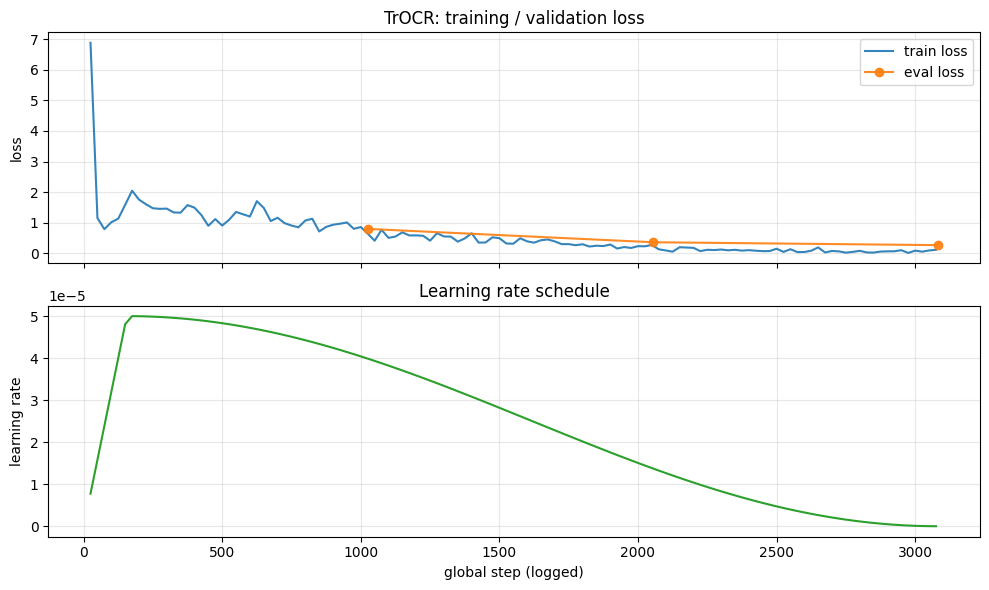

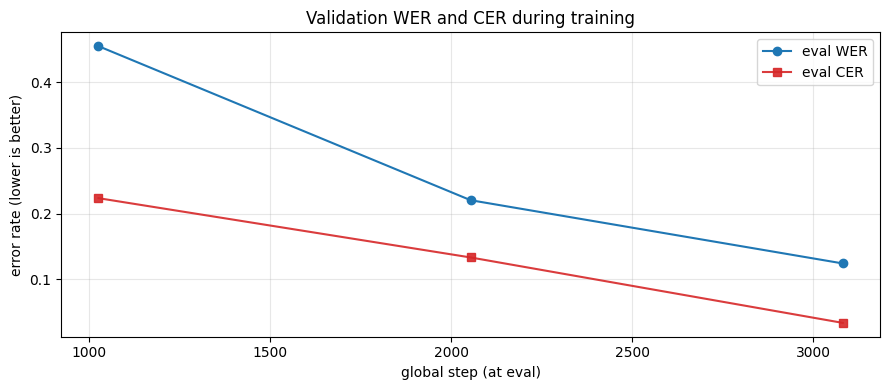

In [29]:
# Plots: loss, LR, validation WER/CER (from `trainer_state.json` -> `log_history`)
state_path = OUTPUT_DIR / "trainer_state.json"
if not state_path.is_file():
    # HF Trainer writes trainer_state.json inside checkpoint-* when save_strategy is enabled.
    checkpoint_states = sorted(
        OUTPUT_DIR.glob("checkpoint-*/trainer_state.json"),
        key=lambda p: p.stat().st_mtime,
    )
    if checkpoint_states:
        state_path = checkpoint_states[-1]
        print(f"Using trainer state from latest checkpoint: {state_path}")
    else:
        raise FileNotFoundError(
            f"Missing {state_path.resolve()!s} and no checkpoint-*/trainer_state.json found. "
            "Run the training cell above first, or fix OUTPUT_DIR / notebook working directory."
        )
with open(state_path) as f:
    tstate = json.load(f)
logs: List[dict] = tstate.get("log_history", [])


def log_series(*keys: str) -> List[Tuple[int, float]]:
    """First matching key with any points wins (HF usually logs `eval_wer`, not `wer`)."""
    for key in keys:
        pts: List[Tuple[int, float]] = []
        for i, row in enumerate(logs):
            if key in row:
                st = int(row.get("step", i))
                pts.append((st, float(row[key])))
        if pts:
            return pts
    return []


tloss = log_series("loss")
eloss = log_series("eval_loss")
elr = log_series("learning_rate")
ewer = log_series("eval_wer", "wer")
ecer = log_series("eval_cer", "cer")

# Helpful if custom metrics are renamed in a future `transformers` version
if logs and not ewer and not ecer:
    sample_eval = sorted(
        {k for r in logs for k in r if str(k).startswith("eval_")}
        - {"eval_loss", "eval_runtime", "eval_samples_per_second", "eval_steps_per_second"}
    )
    if sample_eval:
        print("Tip: `log_history` has no eval_wer/eval_cer; eval_* keys present:", sample_eval)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
if tloss:
    sx, sy = zip(*tloss)
    axes[0].plot(sx, sy, label="train loss", color="C0", alpha=0.9)
if eloss:
    sx, sy = zip(*eloss)
    axes[0].plot(sx, sy, label="eval loss", color="C1", marker="o", alpha=0.9)
axes[0].set_ylabel("loss")
axes[0].set_title("TrOCR: training / validation loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
if elr:
    sx, sy = zip(*elr)
    axes[1].plot(sx, sy, color="C2")
axes[1].set_xlabel("global step (logged)")
axes[1].set_ylabel("learning rate")
axes[1].set_title("Learning rate schedule")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(1, 1, figsize=(9, 4))
if ewer:
    sx, sy = zip(*ewer)
    ax2.plot(sx, sy, label="eval WER", marker="o", color="C0")
if ecer:
    sx, sy = zip(*ecer)
    ax2.plot(sx, sy, label="eval CER", marker="s", color="C3", alpha=0.9)
ax2.set_xlabel("global step (at eval)")
ax2.set_ylabel("error rate (lower is better)")
ax2.set_title("Validation WER and CER during training")
if ewer or ecer:
    ax2.legend()
ax2.grid(True, alpha=0.3)
if not ewer and not ecer and logs:
    ax2.set_title("No WER/CER in log_history (re-run training with compute_metrics)")
plt.tight_layout()
plt.show()

In [30]:
def evaluate_model_on_df(
    mdl: VisionEncoderDecoderModel,
    proc: TrOCRProcessor,
    df: pd.DataFrame,
    image_dir: Path,
    batch_size: int = 4,
    device: Optional[torch.device] = None,
    num_beams: int = GEN_NUM_BEAMS,
    max_length: int = GEN_MAX_LEN,
) -> dict:
    """Run `generate` on all rows; return metrics and per-line paths/refs/preds."""
    if device is None:
        device = next(mdl.parameters()).device
    mdl.eval()
    mdl.to(device)

    tok = proc.tokenizer
    pad = int(tok.pad_token_id)
    eos = int(tok.eos_token_id) if tok.eos_token_id is not None else pad

    names = df["Images"].astype(str).tolist()
    refs = df["Text"].astype(str).tolist()
    image_dir = Path(image_dir)
    paths: List[Path] = [image_dir / n for n in names]
    preds: List[str] = []

    # bf16 if available, else fp16 on CUDA, else no autocast.
    if device.type == "cuda":
        amp_dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
        amp_ctx = torch.autocast(device_type="cuda", dtype=amp_dtype)
    else:
        amp_ctx = nullcontext()

    with torch.inference_mode(), amp_ctx:
        for s0 in range(0, len(paths), batch_size):
            part = paths[s0 : s0 + batch_size]
            imgs = [Image.open(p).convert("RGB") for p in part]
            enc = proc(images=imgs, return_tensors="pt")
            px = enc["pixel_values"].to(device)
            gen = mdl.generate(
                px,
                max_length=max_length,
                num_beams=num_beams,
                pad_token_id=pad,
                eos_token_id=eos,
            )
            out = proc.batch_decode(gen, skip_special_tokens=True, clean_up_tokenization_spaces=True)
            preds.extend(out)
    m = corpus_metrics(refs, preds)
    return {
        **m,
        "n_samples": len(refs),
        "paths": [str(p) for p in paths],
        "refs": list(refs),
        "preds": list(preds),
    }

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mdl_base = VisionEncoderDecoderModel.from_pretrained(PRETRAINED)
mdl_base.to(device)
align_model_to_processor(mdl_base, processor)
res_base = evaluate_model_on_df(
    mdl_base,
    processor,
    test_df,
    TEST_IMAGE_DIR,
    batch_size=EVAL_BATCH,
    device=device,
    num_beams=FINAL_EVAL_NUM_BEAMS,
)

mdl_ft = VisionEncoderDecoderModel.from_pretrained(OUTPUT_DIR)
mdl_ft.to(device)
proc_out = TrOCRProcessor.from_pretrained(OUTPUT_DIR)
align_model_to_processor(mdl_ft, proc_out)
res_ft = evaluate_model_on_df(
    mdl_ft,
    proc_out,
    test_df,
    TEST_IMAGE_DIR,
    batch_size=EVAL_BATCH,
    device=device,
    num_beams=FINAL_EVAL_NUM_BEAMS,
)

summary = pd.DataFrame(
    {
        "Model": ["base (pretrained)", "fine-tuned"],
        "WER": [res_base["wer"], res_ft["wer"]],
        "CER": [res_base["cer"], res_ft["cer"]],
        "Line acc (exact)": [res_base["seq_acc"], res_ft["seq_acc"]],
        "n (test)": [res_base["n_samples"], res_ft["n_samples"]],
    }
)
print(summary.to_string(index=False))
print()
print(
    "Delta (base - fine)  WER:",
    round(res_base["wer"] - res_ft["wer"], 6),
    "  CER:",
    round(res_base["cer"] - res_ft["cer"], 6),
)

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

            Model      WER      CER  Line acc (exact)  n (test)
base (pretrained) 1.379143 0.682457          0.078027      1115
       fine-tuned 1.355699 1.031399          0.000000      1115

Delta (base - fine)  WER: 0.023444   CER: -0.348942


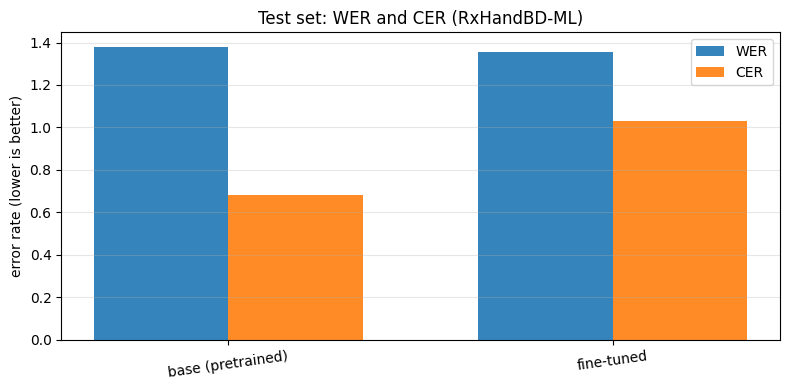

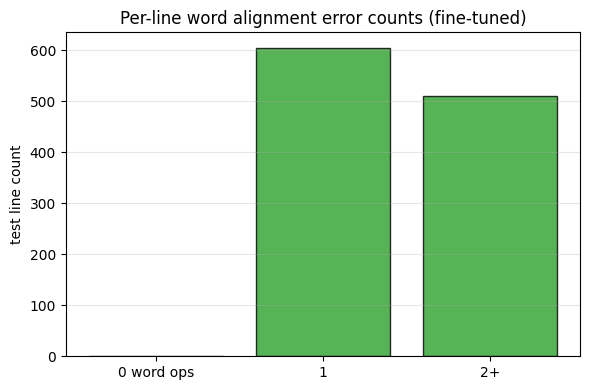

In [32]:
# Test set: grouped bar (WER / CER) + bucketed word error counts
x = np.arange(2)
w = 0.35
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.bar(
    x - w / 2, [res_base["wer"], res_ft["wer"]], w, label="WER", color="C0", alpha=0.9
)
ax.bar(
    x + w / 2, [res_base["cer"], res_ft["cer"]], w, label="CER", color="C1", alpha=0.9
)
ax.set_xticks(x, ["base (pretrained)", "fine-tuned"], rotation=8)
ax.set_ylabel("error rate (lower is better)")
ax.set_title("Test set: WER and CER (RxHandBD-ML)")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

e_ft = per_line_word_error_counts(res_ft["refs"], res_ft["preds"])
b0 = sum(1 for e in e_ft if e == 0)
b1 = sum(1 for e in e_ft if e == 1)
b2p = sum(1 for e in e_ft if e >= 2)
fig2, ax2 = plt.subplots(1, 1, figsize=(6, 4))
ax2.bar(
    ["0 word ops", "1", "2+"],
    [b0, b1, b2p],
    color="C2",
    edgecolor="black",
    alpha=0.8,
)
ax2.set_ylabel("test line count")
ax2.set_title("Per-line word alignment error counts (fine-tuned)")
ax2.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

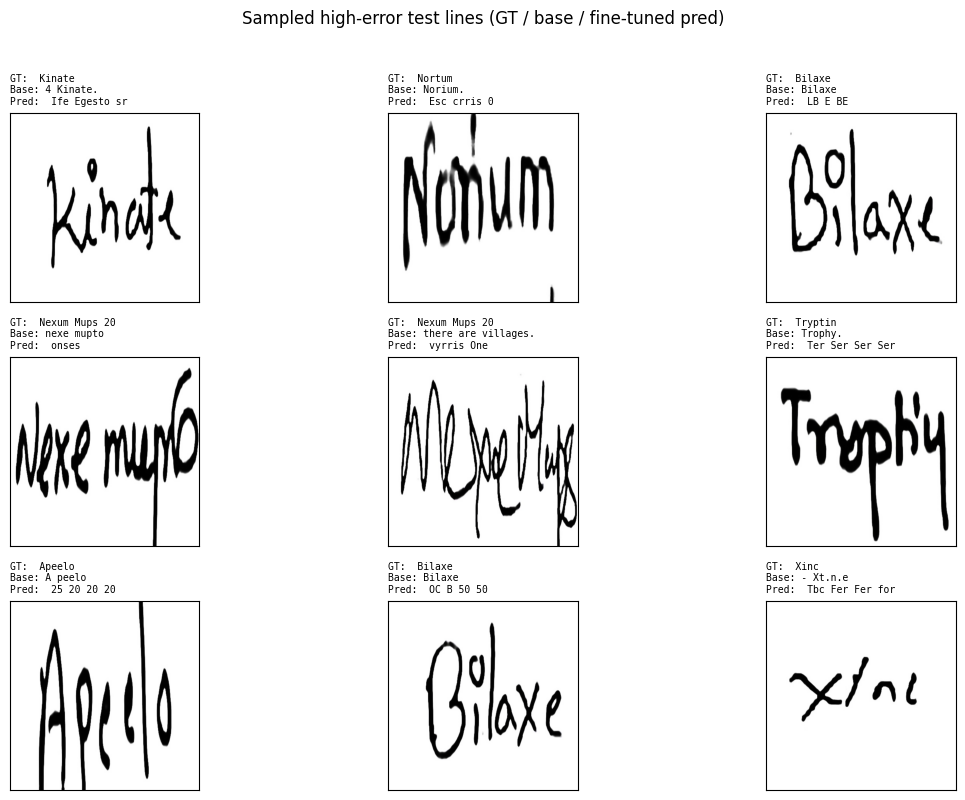

In [33]:
# Hard examples: sort mistakes by word ops, then sample with a fixed seed
HARD_N = 9
HARD_SEED = 7
rng = random.Random(HARD_SEED)

ops = per_line_word_error_counts(res_ft["refs"], res_ft["preds"])
wrong = [i for i, (r, p) in enumerate(zip(res_ft["refs"], res_ft["preds"])) if r != p]
wrong.sort(key=lambda j: -ops[j])
cand = wrong[: max(3 * HARD_N, HARD_N)]
pick = rng.sample(cand, k=min(HARD_N, len(cand))) if cand else []
pick.sort()

if not pick:
    print("No incorrect predictions on the test set to display.")
else:
    nc, nr = 3, int(np.ceil(len(pick) / 3))
    fig, axes = plt.subplots(nr, nc, figsize=(4.2 * nc, 2.6 * nr))
    axes = np.array(axes).ravel()
    for k, ax in enumerate(axes):
        if k >= len(pick):
            ax.axis("off")
            continue
        j = pick[k]
        im = Image.open(res_ft["paths"][j]).convert("RGB")
        ax.imshow(im)
        t = f"GT:  {res_ft['refs'][j]}\nBase: {res_base['preds'][j]}\nPred:  {res_ft['preds'][j]}"
        ax.set_title(t, fontsize=7, family="monospace", loc="left")
        ax.set_xticks([])
        ax.set_yticks([])
    plt.suptitle("Sampled high-error test lines (GT / base / fine-tuned pred)", y=1.02)
    plt.tight_layout()
    plt.show()